# Importing dependencies

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Configuring graphs

In [2]:
plt.rc('font', **{'family':'serif', 'size': 10})
plt.rc('mathtext', **{'fontset':'cm'})
image_resolution = 600
fontsize_label = 12
fontsize_text = 18
fontsize_legend = 10
markers = ['o', 'v', 's', 'X', 'P', 'p', 'D', 'd', 'H', 'h', 'x', '+', '*', '1', '2', '|', '_']
marker_size = 6
cap_size = 3.0
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'teal', 'navy', 'maroon', 'lime']

# Thermophysical properties

In [3]:
def rho(temperature, salinity):
    a = [9.999e2, 2.034e-2, -6.162e-3, 2.261e-5, -4.657e-8]
    b = [8.020e2, -2.001, 1.677e-2, -3.060e-5, -1.613e-5]

    temperature_part = a[0] + a[1] * temperature
    temperature_part += a[2] * temperature * temperature
    temperature_part += a[3] * temperature * temperature * temperature
    temperature_part += a[4] * temperature * temperature * temperature * temperature

    salinity_part = b[0] * salinity
    salinity_part += b[1] * salinity * temperature
    salinity_part += b[2] * salinity * temperature * temperature
    salinity_part += b[3] * salinity * temperature * temperature * temperature
    salinity_part += b[4] * salinity * salinity * temperature * temperature

    return temperature_part + salinity_part

# Establishing directories

In [4]:
figures_dir = os.path.join('./figures/table_2_data/')

os.system('mkdir -p ' + figures_dir)


0

# Loading the cases

In [5]:
cases = pd.read_csv('table_2_data.csv')

def parse_value_with_uncertainty(value):
    if pd.isna(value):
        return np.nan, np.nan

    text = str(value).strip().replace(',', '.')
    if '±' in text:
        value_str, uncertainty_str = [part.strip() for part in text.split('±', 1)]
        return pd.to_numeric(value_str, errors='coerce'), pd.to_numeric(uncertainty_str, errors='coerce')

    numeric_value = pd.to_numeric(text, errors='coerce')
    return numeric_value, np.nan

flux_parsed = cases['J_e [L h^-1 m^-2]'].apply(parse_value_with_uncertainty)
coolant_out_parsed = cases['T_CO,e [°C]'].apply(parse_value_with_uncertainty)

cases['Feed temperature at the inlet (°C)'] = pd.to_numeric(cases['T_EI [°C]'], errors='coerce')
cases['Coolant temperature at the inlet (°C)'] = pd.to_numeric(cases['T_CI [°C]'], errors='coerce')
cases['Feed salinity at the inlet (g/L)'] = pd.to_numeric(cases['S [g L^-1]'], errors='coerce')
cases['Flow rate (L/h)'] = pd.to_numeric(cases['F_FR [L h^-1]'], errors='coerce')

cases['Distilled water flux (L/m²h)'] = flux_parsed.apply(lambda item: item[0])
cases['Distilled water flux uncertainty (L/m²h)'] = flux_parsed.apply(lambda item: item[1]).fillna(0.0)

cases['Coolant temperature at the outlet (°C)'] = coolant_out_parsed.apply(lambda item: item[0])
cases['Coolant temperature at the outlet uncertainty (°C)'] = coolant_out_parsed.apply(lambda item: item[1]).fillna(0.0)

cases['Feed temperature at the outlet (°C)'] = np.nan
cases['Feed temperature at the outlet uncertainty (°C)'] = 0.0

cases['Vacuum pressure (Pa)'] = 50000.0
cases['Membrane area (m²)'] = 12.96
cases['Number of channels'] = 6

cases['Case'] = 'table2-' + (cases.index + 1).astype(str)

numeric_columns = [
    'Feed temperature at the inlet (°C)',
    'Coolant temperature at the inlet (°C)',
    'Vacuum pressure (Pa)',
    'Feed salinity at the inlet (g/L)',
    'Membrane area (m²)',
    'Number of channels',
    'Distilled water flux (L/m²h)',
    'Distilled water flux uncertainty (L/m²h)',
    'Feed temperature at the outlet (°C)',
    'Feed temperature at the outlet uncertainty (°C)',
    'Coolant temperature at the outlet (°C)',
    'Coolant temperature at the outlet uncertainty (°C)',
    'Flow rate (L/h)'
]
cases[numeric_columns] = cases[numeric_columns].apply(pd.to_numeric, errors='coerce')

display(cases)


,caso,sequencia,Feed temperature at the inlet (°C),Coolant temperature at the inlet (°C),Flow rate (L/h),Vacuum pressure (Pa),Feed salinity at the inlet (g/L),Membrane area (m²),Number of channels,Distilled water flux (L/m²h),Distilled water flux uncertainty (L/m²h),Feed temperature at the outlet (°C),Feed temperature at the outlet uncertainty (°C),Coolant temperature at the outlet (°C),Coolant temperature at the outlet uncertainty (°C),Case
0,10 gL,1,60.0,27.0,600,49633,10.0,12.96,6,1.50,0.1,32.0,0.1,56.0,0.5,10 gL-1
1,10 gL,2,65.0,27.0,600,49610,10.0,12.96,6,1.80,0.1,32.3,0.1,60.3,0.1,10 gL-2
2,10 gL,3,67.3,27.0,600,49638,10.0,12.96,6,1.90,0.1,32.3,0.1,62.5,0.3,10 gL-3
3,10 gL,4,69.2,27.0,600,49430,10.0,12.96,6,2.10,0.1,32.6,0.1,64.3,0.1,10 gL-4
4,10 gL,5,65.0,30.0,300,49855,10.0,12.96,6,0.90,0.1,33.6,0.7,61.8,0.3,10 gL-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,210.4 gL,7,80.0,20.0,750,81325,210.4,25.92,12,0.77,NaN,NaN,NaN,72.9,NaN,210.4 gL-7
178,210.4 gL,8,80.0,30.0,750,81325,210.4,25.92,12,0.45,NaN,NaN,NaN,73.9,NaN,210.4 gL-8
179,210.4 gL,9,80.0,25.0,1100,81325,210.4,25.92,12,1.36,NaN,NaN,NaN,72.5,NaN,210.4 gL-9
180,245.5 gL,1,60.0,20.0,1100,81325,245.5,25.92,12,0.41,NaN,NaN,NaN,53.7,NaN,245.5 gL-1


# Running the cases

In [6]:
def salinity_equation(x, salinity, temperature):
    return rho(temperature, x) * x - salinity

In [8]:
results = pd.DataFrame(columns=[
    'Case', 'Permeate flux (L/m²h)', 'Exp. permeate flux (L/m²h)', 'Hot feedwater outlet temperature (°C)',
    'Exp. hot feedwater outlet temperature (°C)', 'Cold feedwater outlet temperature (°C)', 'Exp. cold feedwater outlet temperature (°C)',
    'Heat flux (W/m²)', 'Vapor heat flux (W/m²)', 'GOR', 'STECth', 'Thermal efficiency (%)'
])

for index, elem in cases.iterrows():
    hot_feedwater_inlet_temperature = elem['Feed temperature at the inlet (°C)']
    cold_feedwater_inlet_temperature = elem['Coolant temperature at the inlet (°C)']
    vacuum_pressure = -abs(elem['Vacuum pressure (Pa)'])

    initial_guess = elem['Feed salinity at the inlet (g/L)'] / 1000.0
    feed_salinity = fsolve(
        salinity_equation,
        initial_guess,
        args=(elem['Feed salinity at the inlet (g/L)'], elem['Feed temperature at the inlet (°C)'])
    )[0]
    cool_salinity = feed_salinity

    flow_rate = elem['Flow rate (L/h)']
    feed_mass_flow_rate = rho(hot_feedwater_inlet_temperature, feed_salinity) * flow_rate / 3600000.0
    cool_mass_flow_rate = rho(cold_feedwater_inlet_temperature, cool_salinity) * flow_rate / 3600000.0

    membrane_area = elem['Membrane area (m²)']
    number_channels = int(elem['Number of channels'])

    print('Salinity = ', str(elem['Feed salinity at the inlet (g/L)']), ' g/L')
    os.system('./bin/vagmd0Dmodel -entry_temperature_feed ' + str(hot_feedwater_inlet_temperature) +
              ' -entry_temperature_cool ' + str(cold_feedwater_inlet_temperature) +
              ' -feed_mass_flow_rate ' + str(feed_mass_flow_rate) +
              ' -cool_mass_flow_rate ' + str(cool_mass_flow_rate) +
              ' -vacuum_pressure ' + str(vacuum_pressure) +
              ' -entry_salinity_feed ' + str(feed_salinity) +
              ' -entry_salinity_cool ' + str(cool_salinity) +
              ' -membrane_area ' + str(membrane_area) +
              ' -number_channels ' + str(number_channels))

    results_file = pd.read_csv('./results/report.csv')
    latest_result = results_file.iloc[-1]

    mass_flux = latest_result.iloc[11]
    film_temperature = latest_result.iloc[4]
    hot_feedwater_outlet_temperature = latest_result.iloc[1]
    cold_feedwater_outlet_temperature = latest_result.iloc[2]
    heat_flux = latest_result.iloc[13]
    vapor_heat_flux = latest_result.iloc[15]
    GOR = latest_result.iloc[17]
    STECth = latest_result.iloc[19]
    thermal_efficiency = latest_result.iloc[18]

    new_row = pd.DataFrame([{
        'Case': elem['Case'],
        'Permeate flux (L/m²h)': 1000.0 * mass_flux / rho(film_temperature, 0.0),
        'Exp. permeate flux (L/m²h)': elem['Distilled water flux (L/m²h)'],
        'Hot feedwater outlet temperature (°C)': hot_feedwater_outlet_temperature,
        'Exp. hot feedwater outlet temperature (°C)': elem['Feed temperature at the outlet (°C)'],
        'Cold feedwater outlet temperature (°C)': cold_feedwater_outlet_temperature,
        'Exp. cold feedwater outlet temperature (°C)': elem['Coolant temperature at the outlet (°C)'],
        'Heat flux (W/m²)': heat_flux,
        'Vapor heat flux (W/m²)': vapor_heat_flux,
        'GOR': GOR,
        'STECth': STECth,
        'Thermal efficiency (%)': thermal_efficiency
    }])
    results = pd.concat([results, new_row], ignore_index=True)


Salinity =  10.0  g/L


/tmp/ipykernel_24112/1880593460.py:65: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)


Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =

In [9]:
display(results)

,Case,Permeate flux (L/m²h),Exp. permeate flux (L/m²h),Hot feedwater outlet temperature (°C),Exp. hot feedwater outlet temperature (°C),Cold feedwater outlet temperature (°C),Exp. cold feedwater outlet temperature (°C),Heat flux (W/m²),Vapor heat flux (W/m²),GOR,STECth,Thermal efficiency (%)
0,10 gL-1,1.476480,1.50,32.569399,32.0,54.061639,56.0,1442.897165,961.491871,3.034673,214.781286,66.636202
1,10 gL-2,1.785266,1.80,33.110066,32.3,58.377401,60.3,1673.021158,1157.977255,3.275924,198.203873,69.214741
2,10 gL-3,1.933802,1.90,33.335106,32.3,60.376531,62.5,1779.630948,1252.022756,3.387327,191.345354,70.352944
3,10 gL-4,2.056781,2.10,33.517454,32.6,62.026841,64.3,1867.646207,1329.615325,3.471362,186.438247,71.192034
4,10 gL-5,0.891846,0.90,33.282857,33.6,61.232883,61.8,831.981336,578.167539,5.755094,112.703967,69.492850
...,...,...,...,...,...,...,...,...,...,...,...,...
177,210.4 gL-7,1.515891,0.77,27.890038,NaN,70.396018,72.9,1576.758892,784.108567,2.608312,198.598787,49.729136
178,210.4 gL-8,1.143877,0.45,36.874328,NaN,71.927426,73.9,1306.323819,590.938128,2.348404,220.286706,45.236726
179,210.4 gL-9,2.265056,1.36,34.009029,NaN,69.564840,72.5,2040.810753,1163.974343,2.434713,211.431662,57.034899
180,245.5 gL-1,1.082491,0.41,28.302429,NaN,51.002184,53.7,1416.976927,553.656240,1.349488,379.484160,39.073060


In [10]:
100.0 * (results['Permeate flux (L/m²h)'] - results['Exp. permeate flux (L/m²h)']) / results['Exp. permeate flux (L/m²h)']

0       -1.567995
1       -0.818583
2        1.779065
3       -2.058041
4       -0.906024
          ...    
177     96.868948
178    154.194797
179     66.548252
180    164.022220
181    141.289461
Length: 182, dtype: float64

# Plot the results for different salinities

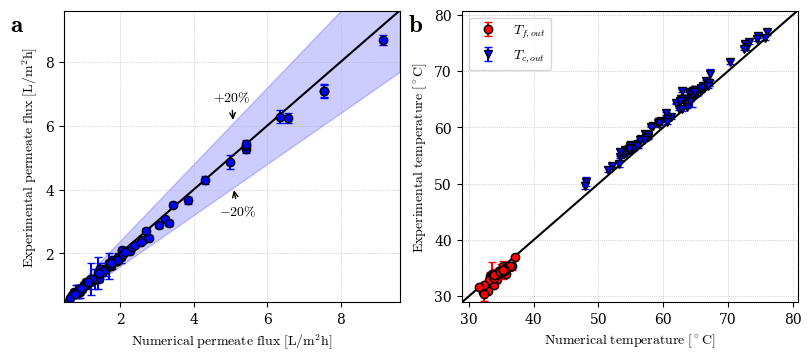

In [11]:
flux_x = results['Permeate flux (L/m²h)'].to_numpy()
flux_y = results['Exp. permeate flux (L/m²h)'].to_numpy()
flux_err = cases['Distilled water flux uncertainty (L/m²h)'].to_numpy()
flux_mask = np.isfinite(flux_x) & np.isfinite(flux_y) & np.isfinite(flux_err)

min_mass_flux = 0.75 * np.nanmin([np.nanmin(flux_x[flux_mask]), np.nanmin(flux_y[flux_mask])])
max_mass_flux = 1.05 * np.nanmax([np.nanmax(flux_x[flux_mask]), np.nanmax(flux_y[flux_mask])])
mass_flux_line = np.linspace(min_mass_flux, max_mass_flux, 100)

hot_x = results['Hot feedwater outlet temperature (°C)'].to_numpy()
hot_y = results['Exp. hot feedwater outlet temperature (°C)'].to_numpy()
hot_err = cases['Feed temperature at the outlet uncertainty (°C)'].to_numpy()
hot_mask = np.isfinite(hot_x) & np.isfinite(hot_y) & np.isfinite(hot_err)

cold_x = results['Cold feedwater outlet temperature (°C)'].to_numpy()
cold_y = results['Exp. cold feedwater outlet temperature (°C)'].to_numpy()
cold_err = cases['Coolant temperature at the outlet uncertainty (°C)'].to_numpy()
cold_mask = np.isfinite(cold_x) & np.isfinite(cold_y) & np.isfinite(cold_err)

temperature_values = np.concatenate([hot_x[hot_mask], hot_y[hot_mask], cold_x[cold_mask], cold_y[cold_mask]])
min_temperature = 0.95 * np.nanmin(temperature_values)
max_temperature = 1.05 * np.nanmax(temperature_values)
temperature_line = np.linspace(min_temperature, max_temperature, 100)

figval, axsval = plt.subplots(nrows=1, ncols=2, figsize=(8.0, 3.5), layout='constrained')

axsval[0].errorbar(
    flux_x[flux_mask],
    flux_y[flux_mask],
    yerr=flux_err[flux_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, linestyle='None'
)
axsval[0].plot(mass_flux_line, mass_flux_line, color='black')
axsval[0].fill_between(mass_flux_line, 0.8 * mass_flux_line, 1.2 * mass_flux_line, color='blue', alpha=0.2)
axsval[0].annotate(r'$\mathrm{+20\%}$', xy=(mass_flux_line[50], 1.2 * mass_flux_line[50]), xytext=(-15, 15), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axsval[0].annotate(r'$\mathrm{-20\%}$', xy=(mass_flux_line[50], 0.8 * mass_flux_line[50]), xytext=(-10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axsval[0].set_xlim(min_mass_flux, max_mass_flux)
axsval[0].set_ylim(min_mass_flux, max_mass_flux)
axsval[0].grid(linestyle='dotted', linewidth=0.5)
axsval[0].set_xlabel(r'$\mathrm{Numerical\ permeate\ flux\ [L/m^2h]}$')
axsval[0].set_ylabel(r'$\mathrm{Experimental\ permeate\ flux\ [L/m^2h]}$')

axsval[1].errorbar(
    hot_x[hot_mask],
    hot_y[hot_mask],
    yerr=hot_err[hot_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[1], capsize=cap_size, label=r'$T_{f,out}$', linestyle='None'
)
axsval[1].errorbar(
    cold_x[cold_mask],
    cold_y[cold_mask],
    yerr=cold_err[cold_mask],
    marker=markers[1], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, label=r'$T_{c,out}$', linestyle='None'
)
axsval[1].plot(temperature_line, temperature_line, color='black')
axsval[1].set_xlim(min_temperature, max_temperature)
axsval[1].set_ylim(min_temperature, max_temperature)
axsval[1].legend(fontsize=fontsize_legend)
axsval[1].grid(linestyle='dotted', linewidth=0.5)
axsval[1].set_xlabel(r'$\mathrm{Numerical\ temperature\ [^\circ C]}$')
axsval[1].set_ylabel(r'$\mathrm{Experimental\ temperature\ [^\circ C]}$')

axsval[0].text(-0.16, 0.93, r'$\mathbf{a}$', transform=axsval[0].transAxes, fontsize=fontsize_text, fontweight='bold')
axsval[1].text(-0.16, 0.93, r'$\mathbf{b}$', transform=axsval[1].transAxes, fontsize=fontsize_text, fontweight='bold')

figval.savefig(figures_dir + 'validation_salinity.svg', dpi=image_resolution, bbox_inches='tight', pad_inches=0.01)


In [13]:
# Quantidade de pontos no gráfico de fluxo de permeado (Gráfico a)
qtd_fluxo = flux_mask.sum()
print(f"Pontos plotados no gráfico de fluxo de permeado: {qtd_fluxo}")

# Quantidade de pontos no gráfico de temperatura (Gráfico b)
qtd_hot = hot_mask.sum()
qtd_cold = cold_mask.sum()
print(f"Pontos Tf,out plotados no gráfico de temperatura: {qtd_hot}")
print(f"Pontos Tc,out plotados no gráfico de temperatura: {qtd_cold}")
print(f"Total de pontos no gráfico de temperatura: {qtd_hot + qtd_cold}")

Pontos plotados no gráfico de fluxo de permeado: 86
Pontos Tf,out plotados no gráfico de temperatura: 41
Pontos Tc,out plotados no gráfico de temperatura: 86
Total de pontos no gráfico de temperatura: 127


In [12]:
import os

# 1. Adiciona uma nova coluna com o desvio percentual absoluto
results['Deviation (%)'] = 100.0 * abs(results['Permeate flux (L/m²h)'] - results['Exp. permeate flux (L/m²h)']) / results['Exp. permeate flux (L/m²h)']

# 2. Cria as máscaras para separar os dados (<= 20% e > 20%)
mask_within_20 = results['Deviation (%)'] <= 20.0
mask_above_20 = results['Deviation (%)'] > 20.0

# 3. Separa os resultados em dois DataFrames distintos
df_within_20 = results[mask_within_20]
df_above_20 = results[mask_above_20]

# 4. Garante que o diretório existe e exporta para CSV
os.makedirs('./results', exist_ok=True)
df_within_20.to_csv('./results/desvios_ate_20.csv', index=False)
df_above_20.to_csv('./results/desvios_acima_de_20.csv', index=False)

print(f"Arquivos CSV gerados com sucesso!")
print(f"-> Casos com desvio de até 20%: {len(df_within_20)}")
print(f"-> Casos com desvio maior que 20%: {len(df_above_20)}")

Arquivos CSV gerados com sucesso!
-> Casos com desvio de até 20%: 138
-> Casos com desvio maior que 20%: 44


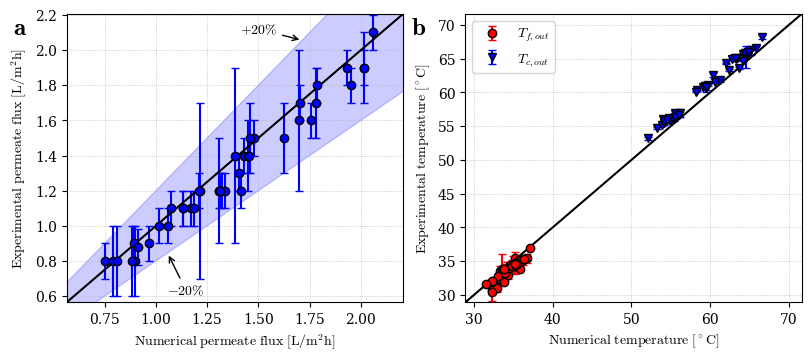

Total de experimentos com informações completas e desvio <= 20%: 41
-> O gráfico 'a' possui 41 pontos plotados.
-> O gráfico 'b' possui 82 pontos plotados (41 de Tf,out e 41 de Tc,out).


In [32]:
# 3. Recalcula os limites do fluxo de permeado
min_mass_flux_final = 0.75 * np.nanmin([np.nanmin(flux_x[final_mask]), np.nanmin(flux_y[final_mask])])
max_mass_flux_final = 1.05 * np.nanmax([np.nanmax(flux_x[final_mask]), np.nanmax(flux_y[final_mask])])

# AJUSTE: Linha base parte de 0 até um valor muito maior, cruzando toda a tela
mass_flux_line_final = np.linspace(0, max_mass_flux_final * 1.5, 100)

# 4. Recalcula os limites de temperatura
temp_values_final = np.concatenate([
    hot_x[final_mask], hot_y[final_mask], 
    cold_x[final_mask], cold_y[final_mask]
])
min_temp_final = 0.95 * np.nanmin(temp_values_final)
max_temp_final = 1.05 * np.nanmax(temp_values_final)

# AJUSTE: Fazemos o mesmo para a reta de temperaturas
temp_line_final = np.linspace(0, max_temp_final * 1.5, 100)

# 5. Configura a figura com dois gráficos (1 linha, 2 colunas)
fig_final, axs_final = plt.subplots(nrows=1, ncols=2, figsize=(8.0, 3.5), layout='constrained')

# ----------------- Gráfico a: Fluxo de Permeado (Desvio <= 20%) -----------------
axs_final[0].errorbar(
    flux_x[final_mask],
    flux_y[final_mask],
    yerr=flux_err[final_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, linestyle='None'
)
axs_final[0].plot(mass_flux_line_final, mass_flux_line_final, color='black')
axs_final[0].fill_between(mass_flux_line_final, 0.8 * mass_flux_line_final, 1.2 * mass_flux_line_final, color='blue', alpha=0.2)

# AJUSTE: Coordenadas calculadas dinamicamente com base na área visível
# Pegamos pontos que estão a 30% (para o -20%) e a 70% (para o +20%) da janela visível
x_range = max_mass_flux_final - min_mass_flux_final
x_down = min_mass_flux_final + 0.30 * x_range
x_up = min_mass_flux_final + 0.70 * x_range

axs_final[0].annotate(r'$\mathrm{+20\%}$', xy=(x_up, 1.2 * x_up), 
                      xytext=(-45, 5), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axs_final[0].annotate(r'$\mathrm{-20\%}$', xy=(x_down, 0.8 * x_down), 
                      xytext=(0, -30), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

# AJUSTE: Trava os eixos firmemente para recortar as sobras da linha e evitar margens em branco
axs_final[0].set_xlim(min_mass_flux_final, max_mass_flux_final)
axs_final[0].set_ylim(min_mass_flux_final, max_mass_flux_final)
axs_final[0].grid(linestyle='dotted', linewidth=0.5)
axs_final[0].set_xlabel(r'$\mathrm{Numerical\ permeate\ flux\ [L/m^2h]}$')
axs_final[0].set_ylabel(r'$\mathrm{Experimental\ permeate\ flux\ [L/m^2h]}$')

# ----------------- Gráfico b: Temperaturas -----------------
axs_final[1].errorbar(
    hot_x[final_mask],
    hot_y[final_mask],
    yerr=hot_err[final_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[1], capsize=cap_size, label=r'$T_{f,out}$', linestyle='None'
)
axs_final[1].errorbar(
    cold_x[final_mask],
    cold_y[final_mask],
    yerr=cold_err[final_mask],
    marker=markers[1], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, label=r'$T_{c,out}$', linestyle='None'
)
axs_final[1].plot(temp_line_final, temp_line_final, color='black')
axs_final[1].set_xlim(min_temp_final, max_temp_final)
axs_final[1].set_ylim(min_temp_final, max_temp_final)
axs_final[1].legend(fontsize=fontsize_legend)
axs_final[1].grid(linestyle='dotted', linewidth=0.5)
axs_final[1].set_xlabel(r'$\mathrm{Numerical\ temperature\ [^\circ C]}$')
axs_final[1].set_ylabel(r'$\mathrm{Experimental\ temperature\ [^\circ C]}$')

# ----------------- Formatação Final e Salvamento -----------------
axs_final[0].text(-0.16, 0.93, r'$\mathbf{a}$', transform=axs_final[0].transAxes, fontsize=fontsize_text, fontweight='bold')
axs_final[1].text(-0.16, 0.93, r'$\mathbf{b}$', transform=axs_final[1].transAxes, fontsize=fontsize_text, fontweight='bold')

fig_final.savefig(figures_dir + 'validation_strict_20_percent_fixed.svg', dpi=image_resolution, bbox_inches='tight', pad_inches=0.01)

plt.show()

# 6. Imprime a quantidade
qtd_final = final_mask.sum()
print(f"Total de experimentos com informações completas e desvio <= 20%: {qtd_final}")
print(f"-> O gráfico 'a' possui {qtd_final} pontos plotados.")
print(f"-> O gráfico 'b' possui {qtd_final * 2} pontos plotados ({qtd_final} de Tf,out e {qtd_final} de Tc,out).")

In [33]:
import os

# Filtra o DataFrame de resultados usando a máscara final (completos e <= 20% desvio)
df_casos_grafico = results[final_mask]

# Garante que o diretório existe e exporta para CSV
os.makedirs('./results', exist_ok=True)
caminho_csv = './results/casos_grafico_final.csv'
df_casos_grafico.to_csv(caminho_csv, index=False)

print(f"\nArquivo '{caminho_csv}' gerado com sucesso!")
print(f"Total de linhas exportadas: {len(df_casos_grafico)}")


Arquivo './results/casos_grafico_final.csv' gerado com sucesso!
Total de linhas exportadas: 41
